About this notebook

In [1]:
import numpy as np
import pandas as pd
import os
import operator
import matplotlib
import argparse
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
import corner
import glob
from tqdm import tqdm
import matplotlib.lines as mlines
from scipy.stats import dirichlet
from scipy.stats import loguniform
from functools import reduce
from matplotlib import gridspec
from matplotlib.transforms import (Bbox, TransformedBbox,
                                   blended_transform_factory)
from mpl_toolkits.axes_grid1.inset_locator import (BboxConnector,
                                                   BboxConnectorPatch,
                                                   BboxPatch)

import sys
sys.path.append('/data/wiay/2297403c/amaze_model_select/AMAZE_model_selection/')
from populations.bbh_models import *
from populations.Pop_Flows import FlowModel
from sample.sample import lnlike_disc

/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
np.random.seed(12)
%matplotlib inline
colors = sns.color_palette("colorblind", n_colors=10)
cp = [colors[0], colors[2], colors[4], colors[1], colors[3], colors[6], colors[9], colors[5], colors[8]]
plt.style.use("mpl.sty")

_param_dict = {'mchirp' : {'limits':(0,100), 'fullname':'Chirp Mass [$M_\\odot$]'},
    'q' : {'limits':(0,1), 'fullname':'Mass Ratio'},
    'chieff' : {'limits':(-1,1), 'fullname':'Effective Inspiral Spin'},
    'z' : {'limits':(0,2), 'fullname':'Redshift'},
    }
_hyperparam_dict = {'chib' : {'values':{'chi00':0.0, 'chi01':0.1, 'chi02':0.2, 'chi05':0.5},
        'fullname':'$\\chi_\\mathrm{birth}$',
        'transform':'linear'},
    'alphaCE' : {'values':{'alpha02':0.2, 'alpha05':0.5, 'alpha10':1.0, 'alpha20':2.0, 'alpha50':5.0},
        'fullname':'$\\alpha_\\mathrm{CE}$',
        'transform':'log'}
    }
_channels_dict = {
    'CE':  {'parameters':['chib','alphaCE'], 'fullname':'Common Envelope'},
    'CHE': {'parameters':['chib'], 'fullname':'Chemically Homogeneous Evolution'},
    'GC':  {'parameters':['chib'], 'fullname':'Globular Clusters'},
    'NSC': {'parameters':['chib'], 'fullname':'Nuclear Star Clusters'},
    'SMT': {'parameters':['chib'], 'fullname':'Stable Mass Transfer'}
    }

_submodels_dict= {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, \
1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}

_param_bounds = {"mchirp": (-1.,70), "q": (0.08,1.01), "chieff": (-0.6,1.), "z": (-0.1,3.5)}
_param_ticks = {"mchirp": [0,10,20,30,40,50,60,70], "q": [0.25,0.5,0.75,1], "chieff": [-0.5,0,0.5,1], "z": [0,0.25,0.5,0.75,1.0,1.25]}
_pdf_bounds = {"mchirp": (0,0.075), "q": (0,32), "chieff": (0,17), "z": (0,4)}
_pdf_ticks = {"mchirp": [0.0,0.025,0.050,0.075], "q": [0,10,20,30], "chieff": [0,4,8,12,16], "z": (0,1,2,3,4)}
_labels_dict = {"mchirp": r"$\mathcal{M}$/$M_{\odot}$", "q": r"$q$", \
"chieff": r"$\chi_{\rm eff}$", "z": r"$z$", "chi00": r"$\chi_\mathrm{b}=0.0$", \
"chi01": r"$\chi_\mathrm{b}=0.1$", "chi02": r"$\chi_\mathrm{b}=0.2$", \
"chi05": r"$\chi_\mathrm{b}=0.5$", "alpha02": r"$\alpha_\mathrm{CE}=0.2$", \
"alpha05": r"$\alpha_\mathrm{CE}=0.5$", "alpha10": r"$\alpha_\mathrm{CE}=1.0$", \
"alpha20": r"$\alpha_\mathrm{CE}=2.0$", "alpha50": r"$\alpha_\mathrm{CE}=5.0$", \
"CE": r"$\texttt{CE}$", "CHE": r"$\texttt{CHE}$", "GC": r"$\texttt{GC}$", \
"NSC": r"$\texttt{NSC}$", "SMT": r"$\texttt{SMT}$", \
"chi_b": r"$\chi_\mathrm{b}$", "alpha_CE": r"$\alpha_\mathrm{CE}$"}
_param_label = [_labels_dict["mchirp"],_labels_dict["q"], _labels_dict["chieff"], _labels_dict["z"]]
_Nsamps = 100000
_channel_label =[r'$\beta_{\mathrm{CE}}$',r'$\beta_{\mathrm{CHE}}$',r'$\beta_{\mathrm{GC}}$',r'$\beta_{\mathrm{NSC}}$',r'$\beta_{\mathrm{SMT}}$']
_channel_label_det =[r'$\beta_{\mathrm{CE}}^{\mathrm{det}}$',r'$\beta_{\mathrm{CHE}}^{\mathrm{det}}$',r'$\beta_{\mathrm{GC}}^{\mathrm{det}}$',\
    r'$\beta_{\mathrm{NSC}}^{\mathrm{det}}$',r'$\beta_{\mathrm{SMT}}^{\mathrm{det}}$']
_beta_det_label = r'$p(\beta^{\mathrm{det}})$'

_models_path ='/data/wiay/2297403c/models_reduced.hdf5'

pt = 1./72.27
jour_sizes = {"AAS": {"onecol": 242.26653*pt, "twocol": 242.26653*2*pt},
              # Add more journals below. Can add more properties to each journal
             }

figure_width = jour_sizes["AAS"]["onecol"]

_base_corner_kwargs = dict(
    bins=60,
    smooth=0.9,
    #quantiles=[0.16, 0.84],
    levels=(0.5,0.9,0.99),
    plot_density=True,
    plot_datapoints=True,
    fill_contours=True,
    show_titles=False,
    hist_kwargs=dict(density=True,linewidth=.75),
    contour_kwargs=dict(linewidths=1.),
    labels=_param_label,
    hist2d_kwargs= dict(data_kwargs=dict(alpha=0.01))
)

In [3]:
def connect_bbox(bbox1, bbox2,
                 loc1a, loc2a, loc1b, loc2b,
                 prop_lines, prop_patches=None):
    if prop_patches is None:
        prop_patches = {
            **prop_lines,
            "alpha": prop_lines.get("alpha", 1) * 0.2,
            "clip_on": False,
        }

    c1 = BboxConnector(
        bbox1, bbox2, loc1=loc1a, loc2=loc2a, clip_on=False, **prop_lines)
    c2 = BboxConnector(
        bbox1, bbox2, loc1=loc1b, loc2=loc2b, clip_on=False, **prop_lines)

    bbox_patch1 = BboxPatch(bbox1, **prop_patches)
    bbox_patch2 = BboxPatch(bbox2, **prop_patches)

    p = BboxConnectorPatch(bbox1, bbox2,
                           loc1a=loc1a, loc2a=loc2a, loc1b=loc1b, loc2b=loc2b,
                           clip_on=False,
                           **prop_patches)

    return c1, c2, bbox_patch1, bbox_patch2, p
def zoom_effect02(ax1, ax2, **kwargs):
    """
    ax1 : the main Axes
    ax1 : the zoomed Axes

    Similar to zoom_effect01.  The xmin & xmax will be taken from the
    ax1.viewLim.
    """

    tt = ax1.transScale + (ax1.transLimits + ax2.transAxes)
    trans = blended_transform_factory(ax2.transData, tt)

    mybbox1 = ax1.bbox
    mybbox2 = TransformedBbox(ax1.viewLim, trans)

    prop_patches = {**kwargs, "ec": "none", "alpha": 0.0}

    c1, c2, bbox_patch1, bbox_patch2, p = connect_bbox(
        mybbox1, mybbox2,
        loc1a=3, loc2a=2, loc1b=4, loc2b=1,
        prop_lines=kwargs, prop_patches=prop_patches)

    ax1.add_patch(bbox_patch1)
    ax2.add_patch(bbox_patch2)
    ax2.add_patch(c1)
    ax2.add_patch(c2)
    ax2.add_patch(p)

    return c1, c2, bbox_patch1, bbox_patch2, p

In [12]:
def sample_pop_corner(popsynth_outputs, flow_dir, channel_label, hyperparam_idxs, effectiveNsamps=True, sample_KDE=True):

    print('loading flow and KDE models...')
    channels_dict_subset = {channel_label:_channels_dict[channel_label]}
    model_names, flow = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict, use_flows=True, sensitivity='midhighlatelow')
    if sample_KDE:
        _, KDE_models = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict, use_flows=False, sensitivity='midhighlatelow')

    flow[channel_label].load_model(flow_dir, device='cpu')

    if effectiveNsamps:
        #determine no. effective samples to draw from flow/KDE
        models_dict = dict.fromkeys(popsynth_outputs.keys())
        weights_dict = dict.fromkeys(popsynth_outputs.keys())

        for key in popsynth_outputs.keys():
            models_dict[key] = popsynth_outputs[key][list(_param_dict.keys())]
            weights_dict[key]= popsynth_outputs[key]['weight']
        weights=weights_dict[tuple(hyperparam_idxs)]
        _Nsamps = int((np.sum(weights))**2/(np.sum(weights**2)))

    #sample flow
    print('sampling flow...')
    conditional = [flow[channel_label].hp_vals[i][hyperparam_idxs[i]] for i in range(flow[channel_label].conditionals)]
    flow_samples = flow[channel_label].sample(np.array(conditional),_Nsamps)

    if sample_KDE:
        print('sampling KDE...')
        model_key = [channel_label]
        for i,model_indx in enumerate(hyperparam_idxs):
            smdl_name=list(_hyperparam_dict[list(_hyperparam_dict.keys())[i]]['values'].keys())[model_indx]
            model_key.append(smdl_name)
        print(model_key)
        kde_smdl = reduce(operator.getitem, model_key, KDE_models)
        kde_samples=kde_smdl.sample(_Nsamps)
        return [flow_samples,kde_samples]
    else:
        return [flow_samples]

def make_pop_corner(channel_label, hyperparam_idxs, flow_dir, conditional=None, plot_KDE=True, outdir='.', testCE=False, justplot=True):

    #get training population samples
    popsynth_outputs = get_popsynth_outputs(_models_path, channel_label, _channels_dict)
    models_dict = dict.fromkeys(popsynth_outputs.keys())
    weights_dict = dict.fromkeys(popsynth_outputs.keys())

    for key in popsynth_outputs.keys():
        models_dict[key] = popsynth_outputs[key][list(_param_dict.keys())]
        weights_dict[key]= popsynth_outputs[key]['weight']

    #get samples from models
    #get samples from models, either sampling first or loading from file
    if justplot==False:
        flow_samples, kde_samples = sample_pop_corner(popsynth_outputs, flow_dir, channel_label, hyperparam_idxs=hyperparam_idxs, sample_KDE=plot_KDE)
        if testCE:
            samples = [flow_samples]
        else:
            samples = [flow_samples, kde_samples]
    else:
        if testCE:
            flow_samples= np.load(f"{outdir}/data/{channel_label}_flows_cornersample_testCE.npy")
            samples = [flow_samples]
        else:
            flow_samples= np.load(f"{outdir}/data/{channel_label}_flows_cornersample.npy")
            kde_samples = np.load(f"{outdir}/data/{channel_label}_KDEs_cornersample.npy")
            samples = [flow_samples, kde_samples]
        

    #set colours for plot
    model_kwargs = deepcopy(_base_corner_kwargs)
    corner_kwargs_kde = deepcopy(_base_corner_kwargs)
    corner_kwargs_flow = deepcopy(_base_corner_kwargs)

    if testCE:
        kwargs = [model_kwargs, corner_kwargs_flow]
        colors=['C1', 'royalblue']
        labels=['Underlying Model', 'Normalising Flow']
    else:
        kwargs = [model_kwargs, corner_kwargs_kde, corner_kwargs_flow]
        colors=['C1', 'purple', 'royalblue']
        labels=['Underlying Model', 'KDE', 'Normalising Flow']
    
    for i, kwarg in enumerate(kwargs):
        kwarg["color"] = colors[i]
        kwarg["hist_kwargs"]["color"] = colors[i]

    print('plotting samples')
    #else plot training models, KDE if plotting, and flow last
    if len(hyperparam_idxs) > 1:
        dict_key = tuple(hyperparam_idxs)
    else:
        dict_key = hyperparam_idxs
    fig =corner.corner(models_dict[dict_key],  weights=weights_dict[dict_key], **model_kwargs)
    if plot_KDE==True:
        corner.corner(samples[1], fig=fig, **corner_kwargs_kde)
    corner.corner(samples[0], fig=fig, **corner_kwargs_flow)
    #add legend
    plt.legend(
            handles=[
                mlines.Line2D([], [], color=colors[i], label=labels[i])
                for i in range(len(colors))
            ],
            frameon=False,
            bbox_to_anchor=(1, 4), loc="upper right"
        )

    fig.set_size_inches(figure_width*1.5, figure_width*1.5)

    if plot_KDE==True:
        inset = fig.add_subplot(444)
        ll, bb, ww, hh =inset.get_position().bounds
        inset.set_position([ll-0.2*ww, bb - 0.75*hh, ww, hh])

        inset.hist(flow_samples[:,2], density=True,linewidth=.75,bins=300, color=colors[2], histtype='step')
        inset.hist(kde_samples[:,2], density=True,linewidth=.75,bins=300, color=colors[1], histtype='step')
        inset.hist(models_dict[tuple(hyperparam_idxs)]['chieff'], weights=weights_dict[tuple(hyperparam_idxs)],density=True,\
            linewidth=.75,bins=300, color=colors[0], histtype='step')
        inset.set_xlim(-0.05,0.1)
        inset.set_xlabel(r"$\chi_{\rm eff}$")
        inset.set_xticks([0., 0.1])
        inset.tick_params(labelsize=8, length=2, pad=0)
        inset.tick_params(
            axis='y',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            right=False,      # ticks along the bottom edge are off
            left=False,         # ticks along the top edge are off
            labelleft=False)
        zoom_effect02(inset, fig.get_axes()[-7], **dict(alpha=0.8, lw=.8))

    return fig, samples

## Figure 1
### Corner plot of Flow, KDE, and Popsynth samples for CE channel with chi_b=0. and alpha_CE=2.

loading flow and KDE models...


100%|██████████| 20/20 [02:31<00:00,  7.57s/it]


sampling flow...
sampling KDE...
['CE', 'chi00', 'alpha20']


plotting samples


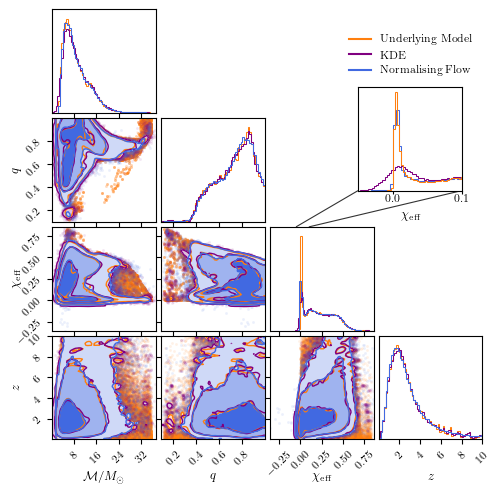

In [13]:
#Figure 1 - sampling from the trained normalising flow
fig,samples = make_pop_corner('CE',[0,3], justplot=False, \
    flow_dir='/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/flow_models/mixed_models/',\
    outdir='/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/plots/prod_091224')
plt.show()

## Figure 2
### Corner plot of Flow with removed test population and Popsynth samples for CE channel with chi_b=0.1 and alpha_CE=1.

loading flow and KDE models...


100%|██████████| 1/1 [01:43<00:00, 103.88s/it]


sampling flow...


plotting samples


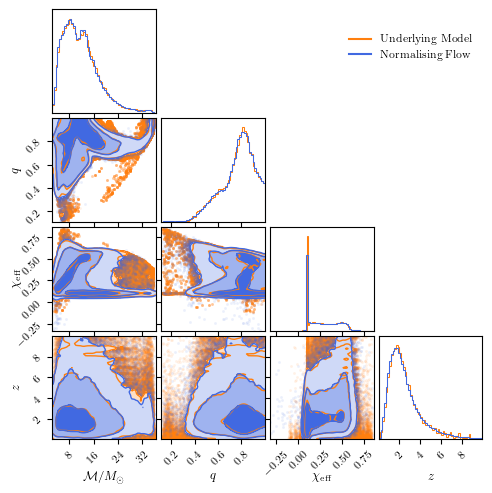

In [63]:
#Fig 2 Test CE plot
fig,samples = make_pop_corner('CE',[1,2], plot_KDE=False, testCE=True, justplot=False,\
    flow_dir='/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/flow_models/CE_test_population/')
plt.show()

In [71]:
#Fig 3. Log likelihood ratio plot
def calc_llh_ratio_CE(flow_dir, outdir='.'):

    channel_label = 'CE'
    channels_dict_subset = {channel_label:_channels_dict[channel_label]}
    popsynth_outputs = get_popsynth_outputs(_models_path, channel_label, _channels_dict)

    print('loading flows/KDEs')
    model_names, flow = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict, use_flows=True, sensitivity='midhighlatelow')
    _, KDE_models = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict, use_flows=False, sensitivity='midhighlatelow')


    #load flow model
    flow[channel_label].load_model(flow_dir, device='cpu')

    #initialise grid of M, q, and p(M,q|chieff,z)
    mchirps = np.linspace(4.,49.9,20)
    qs = np.linspace(0.01,0.99,20)

    p_mchirpq_unreg = np.zeros((20,20))
    p_mchirpq_kde_unreg = np.zeros((20,20))
    p_mchirpq_reg = np.zeros((20,20))
    p_mchirpq_kde_reg = np.zeros((20,20))
    chi_b_id = 0
    alpha_id = 4

    #find log likelihoods for flow and KDE, with and without regularisation
    print('caclulating log likelihoods')
    for  i, m in enumerate(tqdm(mchirps)):
        for j, q in enumerate(qs):
            sample = np.reshape([m, q,0.05,0.2], (1,1,4))
            p_mchirpq_reg[i, j] = lnlike_disc([chi_b_id,alpha_id], sample, flow, _submodels_dict, ['CE'], use_flows=True,\
                 prior_pdf=None, smallest_N=990903)
            p_mchirpq_kde_reg[i, j] = lnlike_disc([chi_b_id,alpha_id], sample, KDE_models, _submodels_dict, ['CE'], use_flows=False,\
                 prior_pdf=None, smallest_N=990903)
            
            p_mchirpq_unreg[i, j] = lnlike_disc([chi_b_id,alpha_id], sample, flow, _submodels_dict, ['CE'], use_flows=True,\
                 prior_pdf=None, smallest_N=None)
            p_mchirpq_kde_unreg[i, j] = lnlike_disc([chi_b_id,alpha_id], sample, KDE_models, _submodels_dict, ['CE'], use_flows=False,\
                 prior_pdf=None, smallest_N=None)

    #convert to log base 10
    llh_ratio_kde_flow_reg = np.log10(np.exp(p_mchirpq_reg-p_mchirpq_kde_reg))
    llh_ratio_kde_flow_unreg = np.log10(np.exp(p_mchirpq_unreg-p_mchirpq_kde_unreg))

    return mchirps, qs, llh_ratio_kde_flow_reg, llh_ratio_kde_flow_unreg

def plot_llh_ratio_CE(flow_dir, outdir, justplot=False):
    plt.rcParams['figure.figsize'] = [figure_width, figure_width*1.2]
    channel_label = 'CE'
    
    #get plot data
    if justplot:
        mchirps = np.linspace(4.,49.9,20)
        qs = np.linspace(0.01,0.99,20)
        llh_ratio_kde_flow_reg = np.load(f"{outdir}/data/llh_ratio_kde_flow_reg.npy")
        llh_ratio_kde_flow_unreg = np.load(f"{outdir}/data/llh_ratio_kde_flow_unreg.npy")
    else:
        mchirps, qs, llh_ratio_kde_flow_reg, llh_ratio_kde_flow_unreg = calc_llh_ratio_CE(flow_dir, outdir)

    #load popsynth models
    popsynth_outputs = get_popsynth_outputs(_models_path, channel_label, _channels_dict)
    models_dict = dict.fromkeys(popsynth_outputs.keys())
    weights_dict = dict.fromkeys(popsynth_outputs.keys())

    for key in popsynth_outputs.keys():
        models_dict[key] = popsynth_outputs[key][list(_param_dict.keys())]
        weights_dict[key]= popsynth_outputs[key]['weight']

    chi_b_id = 0
    alpha_id = 4
    
    fig, ax = plt.subplots(2,1)

    #plot
    print('plotting ratios')
    for row, ratio in enumerate([llh_ratio_kde_flow_unreg, llh_ratio_kde_flow_reg]):
        cbar_scale = np.max(np.abs(ratio))
        c = ax[row].imshow(np.swapaxes(ratio, 0,1), extent=(mchirps[0], mchirps[-1], qs[0], qs[-1]), origin='lower',\
            vmin=-cbar_scale, vmax=cbar_scale, aspect='auto', cmap='RdBu')
        cbar = fig.colorbar(c, ax=ax[row], cmap='RdBu')
        cbar.set_label(r'log$_{10}$ (p$_\mathrm{flow}/$p$_\mathrm{KDE}$)')

        #find popsynth data in bin around slice
        bin_width = 0.05
        chieffs = popsynth_outputs[(chi_b_id,alpha_id)][:]['chieff']
        zs = popsynth_outputs[(chi_b_id,alpha_id)][:]['z']
        bin_chieff = np.logical_and(chieffs>0.0 - 2*bin_width,  chieffs< 0.0 + 2*bin_width)
        bin_z = np.logical_and(zs>0.2 - 10*bin_width, zs < 0.2 + 10*bin_width)
        bin_conditions = np.logical_and(bin_chieff, bin_z)

        c = ax[row].imshow(np.swapaxes(ratio,0,1), extent=(mchirps[0], mchirps[-1], qs[0], qs[-1]), origin='lower',\
            vmin=-cbar_scale, vmax=cbar_scale, aspect='auto', zorder=-200, cmap='RdBu')

        corner.hist2d(np.array(popsynth_outputs[(chi_b_id,alpha_id)][bin_conditions]['mchirp']),\
            np.array(popsynth_outputs[(chi_b_id,alpha_id)][bin_conditions]['q']), bins =16, \
            levels=(.50, .90, .99), \
            weights=np.array(weights_dict[(chi_b_id,alpha_id)][bin_conditions]), contour_kwargs=dict(linewidths=.5), \
            pcolor_kwargs=dict(alpha=0.0), density=True, ax=ax[row], no_fill_contours=True,\
            plot_datapoints=False)
        ax[row].set_xlim(mchirps[0], mchirps[-1])
        ax[row].set_ylim(qs[0], qs[-1])
        ax[row].set_ylabel(_labels_dict['q'])
        ax[1].set_xlabel(_labels_dict['mchirp'])


    fig.tight_layout(pad=1.3)
    return fig

loading flows/KDEs


100%|██████████| 20/20 [00:27<00:00,  1.39s/it]


caclulating log likelihoods


100%|██████████| 20/20 [01:30<00:00,  4.51s/it]


plotting ratios


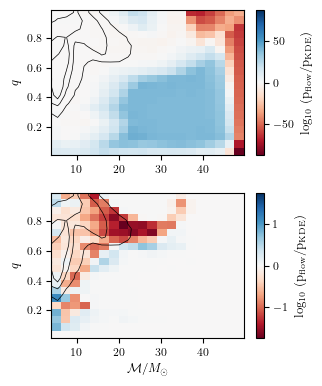

In [85]:
fig = plot_llh_ratio_CE(flow_dir='/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/flow_models/mixed_models/',\
    outdir='/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/plots/prod_091224')

### Aux. function for combining result samples

In [18]:
def load_result_samps(filenames, Nhyper=2, Nchannels=5, detectable=False):
    """
    Loads hyperposterior samples from list of hdf5 files
    filenames : list, array
    """
    samples_allchains = np.array([])
    for i, filename in enumerate(filenames):
        try:
            result = h5py.File(filename, 'r')
        except:
            print(f'file {filename} not found')
            continue
        if detectable:
            result_key = 'detectable_samples'
        else:
            result_key = 'samples'
        samples_file = result['model_selection'][result_key]['block0_values']
        samples_allchains = np.append(samples_allchains, samples_file)
        samples_allchains = np.reshape(samples_allchains, (-1, Nhyper+Nchannels))

    return samples_allchains

## Fig 4
### Discrete inference results

In [81]:
#Fig 4. Discrete Result

def make_1D_result_discrete(filenames, second_files=None):
    plt.rcParams['figure.figsize'] = [figure_width*2, figure_width]
    channels = list(_channels_dict.keys())

    Nhyper =2
    _concentration = np.ones(len(channels))
    beta_p0 =  dirichlet.rvs(_concentration, size=100000)
    beta_bins = np.linspace(0,1,45)

    fig, ax_margs = plt.subplots(2,5, gridspec_kw={'wspace': 0.22, 'hspace': 0.5})
    fig.tight_layout(h_pad=3, w_pad=0.05)

    #add together samples from multiple files
    samples_allchains = load_result_samps(filenames)
    if second_files:
        samples_allchains_comp = load_result_samps(second_files)

    #loop over astrophysical parameters
    for hyper_idx in [0, 1]:
        #loop over population models and plot histograms
        for midx, model in _submodels_dict[hyper_idx].items():
            smdl_locs = np.argwhere(samples_allchains[:,hyper_idx]==midx).flatten()
            if second_files:
                comp_smdl_locs = np.argwhere(samples_allchains_comp[:,hyper_idx]==midx).flatten()

            for cidx, channel in enumerate(channels):
                factor = 50/(len(samples_allchains[:, cidx+Nhyper]))
                h, bins, _ = ax_margs[hyper_idx,cidx].hist(samples_allchains[smdl_locs, cidx+Nhyper], \
                    histtype='step', color=cp[midx], bins=beta_bins, ls='-', lw=1.2, \
                    label=_labels_dict[model],\
                    weights=factor*np.ones_like(samples_allchains[smdl_locs, cidx+Nhyper]))
                if second_files:
                    factor_comp = 50/(len(samples_allchains_comp[:, cidx+Nhyper]))
                    h, bins, _ = ax_margs[hyper_idx,cidx].hist(samples_allchains_comp[comp_smdl_locs, cidx+Nhyper], \
                        histtype='stepfilled', color=cp[midx], bins=beta_bins, \
                        alpha=0.4, \
                        weights=factor_comp*np.ones_like(samples_allchains_comp[comp_smdl_locs, cidx+Nhyper]))
                    h, bins, _ = ax_margs[hyper_idx,cidx].hist(samples_allchains_comp[comp_smdl_locs, cidx+Nhyper], \
                        histtype='step', color=cp[midx], bins=beta_bins, \
                        alpha=0.0, weights=factor_comp*np.ones_like(samples_allchains_comp[comp_smdl_locs, cidx+Nhyper]))

        # format plot
        for cidx, (channel, ax_marg) in enumerate(zip(channels, ax_margs.T)):
            #median branching fractions
            lower_5 = np.percentile(samples_allchains[:, cidx+Nhyper], 5)
            upper_95 = np.percentile(samples_allchains[:, cidx+Nhyper], 95)
            median = np.percentile(samples_allchains[:, cidx+Nhyper], 50)

            #ax_marg[hyper_idx].vlines([lower_5, median, upper_95], 0,20, color='black', alpha=0.5, lw=0.5)

            #plot prior
            h, bins, _ = ax_marg[hyper_idx].hist(beta_p0[:,cidx], \
                    histtype='step', color='grey', bins=20, alpha=0.7, density=True)

            ax_marg[1].set_xlabel(_channel_label[cidx])
            ax_marg[hyper_idx].set_yscale('log')

            ax_marg[hyper_idx].set_xlim(0,1)
            ax_marg[hyper_idx].set_ylim(1e-4,80)
            if cidx == 0:
                ax_marg[hyper_idx].set_ylabel(r"$p(\beta)$")
            else:
                ax_marg[hyper_idx].tick_params(labelleft=False)
        # legend
        if hyper_idx == 0:
            ax_margs[0,0].legend(loc='lower left', bbox_to_anchor=(.7, 1.02), ncol=4)
        if hyper_idx ==1:
            ax_margs[1,0].legend(loc='lower left', bbox_to_anchor=(-0.05, 1.02), ncol=5)

    plt.subplots_adjust(top=0.85)
    plt.show()

/tmp/ipykernel_1286152/1543577630.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=3, w_pad=0.05)


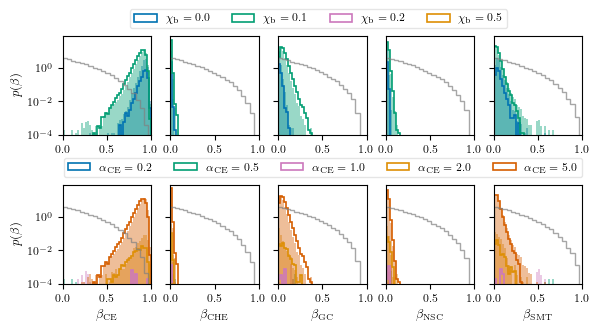

In [92]:
filenames = glob.glob('/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/outputs/discrete_GWTC3/flow_retrainedCE/*.hdf5')
KDE_filenames = glob.glob('/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/outputs/discrete_GWTC3/KDEs/*.hdf5')
make_1D_result_discrete(filenames, second_files=KDE_filenames)

## Fig 5.
### Continuous inference result

In [28]:
#Fig 5. Continuous result
def make_1D_result_continuous(filenames, filenames_det=None):
    channels = list(_channels_dict.keys())
    colors = ['royalblue','lightskyblue','darkblue']
    _concentration = np.ones(len(channels))
    beta_p0 =  dirichlet.rvs(_concentration, size=100000)
    _alpha_CE =np.exp(list(_hyperparam_dict['alphaCE']['values'].values()))
    _chi_b =list(_hyperparam_dict['chib']['values'].values())
    alpha_CE_p0 =  loguniform.rvs(_alpha_CE[0], _alpha_CE[-1], size=100000)
    chib_p0 =  np.random.uniform(0, 0.5, size=100000)
    Nhyper =2

    fig = plt.figure(layout='constrained')
    plt.rcParams['figure.figsize'] = [figure_width*2, figure_width*1.5]
    subfigs = fig.subfigures(3, 1, height_ratios=[1.,1., 1.])
    ax_margs_det = subfigs[2].subplots(1, 5)
    ax_chibalpha = subfigs[0].subplots(1, 2)
    ax_margs = subfigs[1].subplots(1, 5)
    ax_margs_set = [ax_margs, ax_margs_det]
    channel_labels = [_channel_label,_channel_label_det]


    #add together samples from multiple files
    samples_allchains = load_result_samps(filenames)
    sample_sets = np.array([samples_allchains])
    samples_allchains_detectable = load_result_samps([filenames_det], detectable=True)
    sample_sets = [samples_allchains, samples_allchains_detectable]

    #plot posteriors on chi_b and alpha_CE
    h, bins, _ = ax_chibalpha[0].hist(samples_allchains[:, 0], density=True,\
        histtype='step', color=colors[0], bins=np.linspace(0,0.5,80), ls='-', lw=1.5)
    h, bins, _ = ax_chibalpha[1].hist(samples_allchains[:, 1], density=True,\
        histtype='step', color=colors[0], bins=np.linspace(0,5.,50), ls='-', lw=1.5)

    for i, (samples,axes) in enumerate(zip(sample_sets, ax_margs_set)):
        for cidx, channel in enumerate(channels):
            h, bins, _ = axes[cidx].hist(samples[:,cidx+Nhyper], density=True,\
                histtype='step', color=colors[0], bins=np.linspace(0,1.,45), ls='-', lw=1.5)

    # format plot
    chi_b_lim = ax_chibalpha[0].get_ylim()[1] + 50
    alpha_CE_lim = ax_chibalpha[1].get_ylim()[1] +2
    #plot training lines
    ax_chibalpha[0].vlines(_chi_b, ax_chibalpha[0].get_ylim()[0], chi_b_lim, color='black', alpha=0.5)
    #plot chib prior
    ax_chibalpha[0].hist(chib_p0, \
                histtype='step', color='grey', bins=1, alpha=0.7, density=True, zorder=-1000)
    ax_chibalpha[1].vlines(_alpha_CE, ax_chibalpha[1].get_ylim()[0], alpha_CE_lim, color='black', alpha=0.5)
    #plot alpha_CE prior
    ax_chibalpha[1].hist(alpha_CE_p0, \
                histtype='step', color='grey', bins=20, alpha=0.7, density=True, zorder=-1000)

    ax_chibalpha[0].autoscale(tight=True, axis='y')
    ax_chibalpha[1].autoscale(tight=True, axis='y')
    ax_chibalpha[0].set_xlabel(_labels_dict['chi_b'])
    ax_chibalpha[1].set_xlabel(_labels_dict['alpha_CE'])
    #ax_chibalpha[1].set_xscale('log')
    ax_chibalpha[0].set_ylabel(r'$p($'+_labels_dict['chi_b']+r'$)$')
    ax_chibalpha[1].set_ylabel(r'$p($'+_labels_dict['alpha_CE']+r'$)$')

    for cidx, channel in enumerate(channels):
            #plot prior
            h, bins, _ = ax_margs[cidx].hist(beta_p0[:,cidx], \
                    histtype='step', color='grey', bins=20, alpha=0.7, density=True, zorder=-1000)

    for axes, label, samples in zip(ax_margs_set, channel_labels, sample_sets):
        for i, ax_marg in enumerate(np.append(ax_chibalpha, axes).flatten()):

            #median branching fractions
            q_mid = np.percentile(samples[:, i], 50)
            q_m = q_mid - np.percentile(samples[:, i], 5)
            q_p = np.percentile(samples[:, i], 95) - q_mid

            title_fmt=".2f"
            fmt = "{{0:{0}}}".format(title_fmt).format
            title = r"${{{0}}}_{{-{1}}}^{{+{2}}}$"
            title = title.format(fmt(q_mid), fmt(q_m), fmt(q_p))
            ax_marg.set_yscale('log')
            #ax_marg.set_title(fr'${title}$')

            for cidx, channel in enumerate(channels):
                axes[cidx].set_xlabel(label[cidx])
                axes[cidx].set_xlim(0,1)
                ax_margs_set[0][cidx].set_ylim(1e-4,80)
                ax_margs_set[1][cidx].set_ylim(1e-4,15)
                axes[cidx].get_yaxis().set_tick_params(which='minor', size=0)
                #axes[cidx].set_yticks([1e-1,1e1])
                if cidx == 0:
                    ax_margs_set[0][cidx].set_ylabel(r"$p(\beta)$")
                    ax_margs_set[1][cidx].set_ylabel(r'$p(\beta^{\mathrm{det}})$')
                else:
                    axes[cidx].tick_params(labelleft=False)
    plt.show()

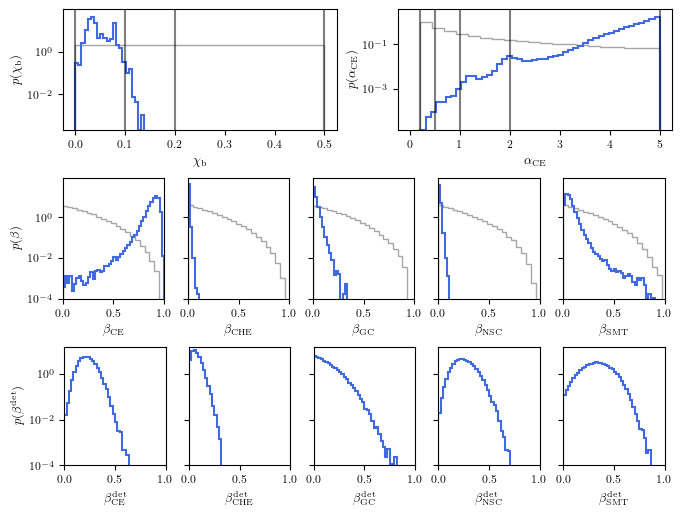

In [29]:
filenames = glob.glob('/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/outputs/cont_GWTC3/prod_retrainedCE/*.hdf5')
make_1D_result_continuous(filenames,\
     filenames_det='/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/plots/prod_091224/data/cont_retrainedCE_detectable_betas.hdf5')

## Fig. 6
### Samples from dataspace

In [43]:
#Fig. 6 Dataspace result
def save_dataspace_samps(filenames, flow_dir, outdir='.'):
    channels = list(_channels_dict.keys())
    params=list(_param_dict.keys())

    print('loading results samples')
    hyper_posts = load_result_samps(filenames, raw_samples=True)

    print('loading flows')
    model_names, flow = get_models(_models_path, _channels_dict, _param_dict, _hyperparam_dict, use_flows=True, sensitivity='midhighlatelow')
    for channel in channels:
        flow[channel].load_model(flow_dir, device='cpu')   

    print('sampling over marginalised hyperparameters')
    #Marginalising over hyperposterior samples
    no_total_samps = 1000000
    samps_per_hyperposts = 10
    no_hypersamps = int(no_total_samps/samps_per_hyperposts)

    samps_filled = np.zeros(6, dtype=int)
    channel_samps = [[],[],[],[],[]]

    for i, hyperpost_idx in enumerate(tqdm(np.random.choice(np.arange(np.shape(hyper_posts)[0]), no_hypersamps, replace=False))):
        hyperpost_samp = hyper_posts[hyperpost_idx,:]

        #evauluate channel as weighted choice according to branching fractions
        channel_idx = np.random.choice(np.arange(len(channels)), p=hyperpost_samp[2:])
        channel = channels[channel_idx]

        #sample flow
        hyperpost_samp[1] = np.log(hyperpost_samp[1])
        samps = flow[channel].sample(np.array(hyperpost_samp[:flow[channel].conditionals]), samps_per_hyperposts)
        
        channel_samps[channel_idx].append(samps)

    #evaluate the cumulative sum of samples with each channel
    no_channel_samps = [np.shape(channel_samps[chnl])[0] for chnl in np.arange(len(channels))]
    samps_filled[:5] = np.cumsum(no_channel_samps, axis=0)*samps_per_hyperposts

    #ordering total samples by channel
    total_samps_ordered = np.zeros((no_total_samps, len(params)))
    for cidx in range(len(channels)):
        channel_samps_red = np.reshape(np.array(channel_samps[cidx]),(-1,len(params)))
        total_samps_ordered[samps_filled[cidx-1]:samps_filled[cidx],:] = channel_samps_red
    
    return total_samps_ordered, samps_filled

def plot_samps_dataspace(filenames=None, flow_dir=None, outdir='.', justplot=False):
    channels = list(_channels_dict.keys())
    params=list(_param_dict.keys())
    
    if justplot==False:
        total_samps_ordered, samps_filled = save_dataspace_samps(filenames, flow_dir, outdir=outdir)
    else:
        total_samps_ordered = np.load(f"{outdir}/data/flow_samps_dataspace.npy")
        samps_filled = np.load(f'{outdir}/data/no_channelsamps_dataspace.npy')

    plt.rcParams["figure.figsize"] = (figure_width*2,figure_width*2/3)
    fig,ax=plt.subplots(1,4)
    cmap = plt.colormaps['plasma']
    colors = cmap(np.linspace(0, 1, 6))

    print('loading parametric samples')
    comb_intrins_samps = pd.read_hdf('/data/wiay/2297403c/GW_ChirpSim/binary_param_generation/60_intrins_samps_zmax1_35.hdf5', key='all_intrins_samps')
    mchirp_samps = comb_intrins_samps['m1']*(comb_intrins_samps['q']**3/(1+comb_intrins_samps['q']))
    chieff_samps = ((comb_intrins_samps['chi_1']*comb_intrins_samps['costilt_1'])+(comb_intrins_samps['q']*comb_intrins_samps['chi_2']*comb_intrins_samps['costilt_2']))\
    /(1+comb_intrins_samps['q'])

    no_total_samps = np.shape(total_samps_ordered)[0]
    PLPP_samps = [mchirp_samps, comb_intrins_samps['q'], chieff_samps, comb_intrins_samps['z']]
    no_bins=50
    bins =np.array([np.linspace(_param_bounds[pidx][0],_param_bounds[pidx][1],no_bins) for pidx in params])
    ax_ylims = [0.6*no_total_samps,0.2*no_total_samps,0.6*no_total_samps,0.12*no_total_samps]
    mask_min = [np.min(total_samps_ordered[:,0]), 0,-1,0]
    mask_max = [100, 1,1,1.35]

    for cidx, channel in enumerate(channels):
        for pidx,param in enumerate(params):
            ax[pidx].hist(total_samps_ordered[samps_filled[cidx-1]:samps_filled[cidx],pidx], color=colors[cidx], histtype='step', bins=bins[pidx], lw=1,\
                label=channel)

    for pidx,param in enumerate(params):
        ax[pidx].hist(total_samps_ordered[:,pidx], color='slategrey', histtype='stepfilled', bins=bins[pidx], lw=1,\
            zorder=-1000, ls='-', label='Total', alpha=.6,)
        mask = np.logical_and(mask_min[pidx]<total_samps_ordered[:,pidx],total_samps_ordered[:,pidx]<mask_max[pidx])
        ax[pidx].hist(PLPP_samps[pidx], color='deeppink', histtype='step',\
            weights=np.ones_like(PLPP_samps[pidx])*len(total_samps_ordered[mask,pidx])/len(PLPP_samps[pidx]),\
            bins=bins[pidx], lw=1, ls='-', label='Parametric', zorder=-100)
        ax[pidx].set_yscale('log')
        ax[pidx].set_xlabel(_labels_dict[param])
        ax[pidx].set_ylim(5,ax_ylims[0])
        ax[pidx].set_xlim(_param_bounds[param][0],_param_bounds[param][1])
        if pidx>0:
            ax[pidx].tick_params(labelleft=False)
    ax[0].set_ylabel('No. samples')
    plt.legend(loc='lower center', bbox_to_anchor=(-1.4, 1.02), ncol=7, columnspacing=1., frameon=False)
    fig.subplots_adjust( left=None, bottom=None,  right=None, top=None, wspace=None, hspace=None)
    fig.tight_layout(pad=1.3)
    plt.show()

In [44]:
filenames = glob.glob('/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/outputs/cont_GWTC3/prod_retrainedCE/*.hdf5')
plot_samps_dataspace(filenames, flow_dir='/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/flow_models/mixed_models/',\
     outdir='.', justplot=False)

loading results samples
loading flows


100%|██████████| 5/5 [03:06<00:00, 37.29s/it] 


sampling over marginalised hyperparameters


  1%|▏         | 1337/100000 [00:19<24:08, 68.12it/s]


KeyboardInterrupt: 

In [ ]:
# KLs